In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import random

# ===================== CONFIG =====================
IMAGE_DIR      = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\train\Original'
MASK_DIR       = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\train\Ground truth'
TEST_IMAGE_DIR = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\test\Original'
TEST_MASK_DIR  = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\test\Ground truth'

RESIZE_SIZE = 512     # Original size of FIVES images
IMG_SIZE    = 128     # Patch size
OVERLAP     = 0.5
BATCH_SIZE  = 8         # Adjust according to GPU
SHUFFLE_BUF = 512

# ===================== AUGMENTATION =====================
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
])

# ===================== UTIL FUNCTIONS =====================
def is_valid_patch(mask, threshold=0.01):
    return np.count_nonzero(mask) / mask.size > threshold

def extract_patches(img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    stride = int(patch_size * (1 - overlap))
    H, W = img.shape[:2]
    patches_img, patches_mask = [], []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            p_img  = img[y:y+patch_size, x:x+patch_size]
            p_mask = mask[y:y+patch_size, x:x+patch_size]

            if skip_empty and not is_valid_patch(p_mask):
                continue

            patches_img.append(p_img)
            patches_mask.append(p_mask)
    
    return patches_img, patches_mask

def load_image_mask_paths(image_dir, mask_dir):
    images = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)
                     if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    masks = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    return images, masks

# ===================== GENERATOR =====================
def generator(image_paths, mask_paths, augment=True, skip_empty=True):
    for img_path, mask_path in zip(image_paths, mask_paths):
        img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img  = cv2.resize(img,  (RESIZE_SIZE, RESIZE_SIZE))
        mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

        patches_img, patches_mask = extract_patches(img, mask, IMG_SIZE, OVERLAP, skip_empty)
        
        for p_img, p_mask in zip(patches_img, patches_mask):
            if augment:
                data = augmenter(image=p_img, mask=p_mask)
                p_img, p_mask = data["image"], data["mask"]

            p_img  = p_img.astype(np.float32) / 255.0
            p_mask = np.expand_dims(p_mask.astype(np.float32) / 255.0, axis=-1)

            yield p_img, p_mask

# ===================== LOAD DATA =====================
all_images, all_masks = load_image_mask_paths(IMAGE_DIR, MASK_DIR)

# Random shuffle for train/val split
combined = list(zip(all_images, all_masks))
random.shuffle(combined)
all_images, all_masks = zip(*combined)

# Validation: 150 images
val_images   = all_images[:150]
val_masks    = all_masks[:150]

# Training: rest of the images
train_images = all_images[150:]
train_masks  = all_masks[150:]

# Test
test_images, test_masks = load_image_mask_paths(TEST_IMAGE_DIR, TEST_MASK_DIR)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

# ===================== TF.DATA DATASETS =====================
output_signature = (
    tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
    tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
)

train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_images, train_masks, augment=True, skip_empty=True),
    output_signature=output_signature
).shuffle(SHUFFLE_BUF).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: generator(val_images, val_masks, augment=False, skip_empty=False),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_images, test_masks, augment=False, skip_empty=False),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Datasets ready: train_ds, val_ds, test_ds")

C:\Users\AUSTCSE4090\anaconda3\envs\py310\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train: 450, Val: 150, Test: 200
✅ Datasets ready: train_ds, val_ds, test_ds


Total patches: 49


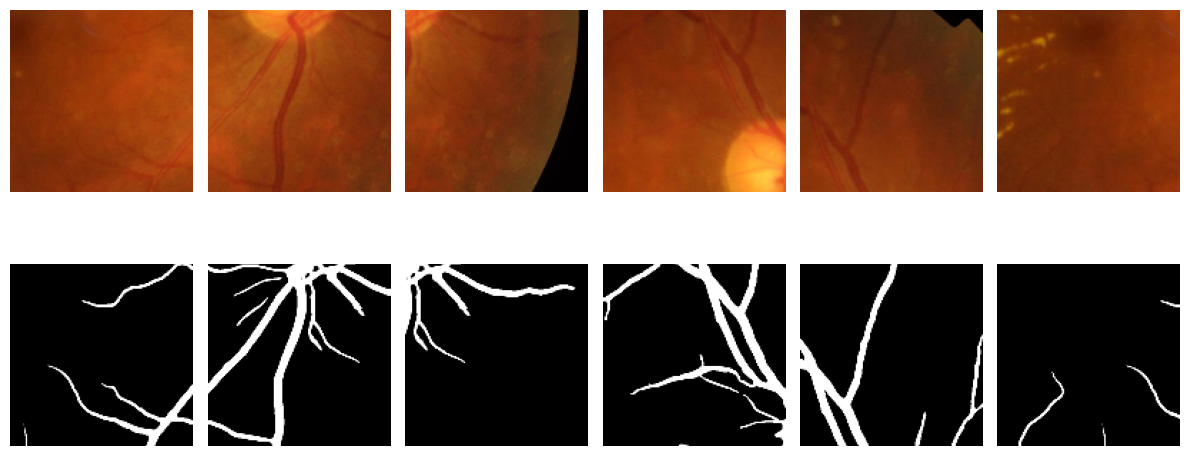

In [2]:
import matplotlib.pyplot as plt

def visualize_patches(img_path, mask_path, num_samples=6):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize for visualization
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
    mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

    patches_img, patches_mask = extract_patches(
        img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=False
    )

    print(f"Total patches: {len(patches_img)}")

    indices = random.sample(range(len(patches_img)), min(num_samples, len(patches_img)))

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        plt.subplot(2, num_samples, i+1)
        plt.imshow(patches_img[idx])
        plt.axis("off")

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(patches_mask[idx], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example visualization
visualize_patches(train_images[0], train_masks[0])


In [3]:
import tensorflow as tf
from tensorflow.keras import backend as K

def confusion_elements(y_true, y_pred):
    """Helper to calculate TP, TN, FP, FN"""
    y_pred = K.round(y_pred)
    y_true = K.round(y_true)
    TP = K.sum(y_true * y_pred)
    TN = K.sum((1 - y_true) * (1 - y_pred))
    FP = K.sum((1 - y_true) * y_pred)
    FN = K.sum(y_true * (1 - y_pred))
    return TP, TN, FP, FN

# Sensitivity (Recall)
def sensitivity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FN + K.epsilon())

# Specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TN / (TN + FP + K.epsilon())

# Accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN + K.epsilon())

# Precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FP + K.epsilon())

# F1-score
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = sensitivity(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec + K.epsilon()))

# AUC (use Keras built-in metric)
auc = tf.keras.metrics.AUC(name='auc')


import tensorflow as tf
import tensorflow.keras.backend as K

smooth = 1e-6

def iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(K.round(y_pred), tf.float32)  # Round to binary
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(K.round(y_pred))  # Round predictions to binary
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [4]:

from __future__ import absolute_import

from keras_unet_collection.layer_utils import *
from keras_unet_collection.activations import GELU, Snake
from keras_unet_collection._model_unet_2d import UNET_left, UNET_right
from keras_unet_collection.transformer_layers import patch_extract, patch_embedding
from keras_unet_collection._backbone_zoo import backbone_zoo, bach_norm_checker

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, MultiHeadAttention, LayerNormalization, Dense, Embedding
    
def ViT_MLP(X, filter_num, activation='GELU', name='MLP'):
    '''
    The MLP block of ViT.
    
    ----------
    Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, 
    T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S. and Uszkoreit, J., 2020. 
    An image is worth 16x16 words: Transformers for image recognition at scale. 
    arXiv preprint arXiv:2010.11929.
    
    Input
    ----------
        X: the input tensor of MLP, i.e., after MSA and skip connections
        filter_num: a list that defines the number of nodes for each MLP layer.
                        For the last MLP layer, its number of node must equal to the dimension of key.
        activation: activation of MLP nodes.
        name: prefix of the created keras layers.
        
    Output
    ----------
        V: output tensor.

    '''
    activation_func = eval(activation)
    
    for i, f in enumerate(filter_num):
        X = Dense(f, name='{}_dense_{}'.format(name, i))(X)
        X = activation_func(name='{}_activation_{}'.format(name, i))(X)
        
    return X
    
def ViT_block(V, num_heads, key_dim, filter_num_MLP, activation='GELU', name='ViT'):
    '''
    
    Vision transformer (ViT) block.
    
    ViT_block(V, num_heads, key_dim, filter_num_MLP, activation='GELU', name='ViT')
    
    ----------
    Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, 
    T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S. and Uszkoreit, J., 2020. 
    An image is worth 16x16 words: Transformers for image recognition at scale. 
    arXiv preprint arXiv:2010.11929.
    
    Input
    ----------
        V: embedded input features.
        num_heads: number of attention heads.
        key_dim: dimension of the attention key (equals to the embeded dimensions).
        filter_num_MLP: a list that defines the number of nodes for each MLP layer.
                        For the last MLP layer, its number of node must equal to the dimension of key.
        activation: activation of MLP nodes.
        name: prefix of the created keras layers.
        
    Output
    ----------
        V: output tensor.
    
    '''
    # Multiheaded self-attention (MSA)
    V_atten = V # <--- skip
    V_atten = LayerNormalization(name='{}_layer_norm_1'.format(name))(V_atten)
    V_atten = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, 
                                 name='{}_atten'.format(name))(V_atten, V_atten)
    # Skip connection
    V_add = add([V_atten, V], name='{}_skip_1'.format(name)) # <--- skip
    
    # MLP
    V_MLP = V_add # <--- skip
    V_MLP = LayerNormalization(name='{}_layer_norm_2'.format(name))(V_MLP)
    V_MLP = ViT_MLP(V_MLP, filter_num_MLP, activation, name='{}_mlp'.format(name))
    # Skip connection
    V_out = add([V_MLP, V_add], name='{}_skip_2'.format(name)) # <--- skip
    
    return V_out


def transunet_2d_base(input_tensor, filter_num, stack_num_down=2, stack_num_up=2, 
                      embed_dim=768, num_mlp=3072, num_heads=12, num_transformer=12,
                      activation='ReLU', mlp_activation='GELU', batch_norm=False, pool=True, unpool=True, 
                      backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):
    '''
    The base of transUNET with an optional ImageNet-trained backbone.
    
    ----------
    Chen, J., Lu, Y., Yu, Q., Luo, X., Adeli, E., Wang, Y., Lu, L., Yuille, A.L. and Zhou, Y., 2021. 
    Transunet: Transformers make strong encoders for medical image segmentation. arXiv preprint arXiv:2102.04306.
    
    Input
    ----------
        input_tensor: the input tensor of the base, e.g., `keras.layers.Inpyt((None, None, 3))`.
        filter_num: a list that defines the number of filters for each \
                    down- and upsampling levels. e.g., `[64, 128, 256, 512]`.
                    The depth is expected as `len(filter_num)`.
        stack_num_down: number of convolutional layers per downsampling level/block. 
        stack_num_up: number of convolutional layers (after concatenation) per upsampling level/block.
        activation: one of the `tensorflow.keras.layers` or `keras_unet_collection.activations` interfaces, e.g., 'ReLU'.
        batch_norm: True for batch normalization.
        pool: True or 'max' for MaxPooling2D.
              'ave' for AveragePooling2D.
              False for strided conv + batch norm + activation.
        unpool: True or 'bilinear' for Upsampling2D with bilinear interpolation.
                'nearest' for Upsampling2D with nearest interpolation.
                False for Conv2DTranspose + batch norm + activation.
        name: prefix of the created keras model and its layers.
        
        ---------- (keywords of ViT) ----------
        embed_dim: number of embedded dimensions.
        num_mlp: number of MLP nodes.
        num_heads: number of attention heads.
        num_transformer: number of stacked ViTs.
        mlp_activation: activation of MLP nodes.
        
        ---------- (keywords of backbone options) ----------
        backbone_name: the bakcbone model name. Should be one of the `tensorflow.keras.applications` class.
                       None (default) means no backbone. 
                       Currently supported backbones are:
                       (1) VGG16, VGG19
                       (2) ResNet50, ResNet101, ResNet152
                       (3) ResNet50V2, ResNet101V2, ResNet152V2
                       (4) DenseNet121, DenseNet169, DenseNet201
                       (5) EfficientNetB[0-7]
        weights: one of None (random initialization), 'imagenet' (pre-training on ImageNet), 
                 or the path to the weights file to be loaded.
        freeze_backbone: True for a frozen backbone.
        freeze_batch_norm: False for not freezing batch normalization layers.
        
    Output
    ----------
        X: output tensor.
    
    '''
    activation_func = eval(activation)
    
    X_skip = []
    depth_ = len(filter_num)
    
    # ----- internal parameters ----- #
    
    # patch size (fixed to 1-by-1)
    patch_size = 1
    
    # input tensor size
    input_size = input_tensor.shape[1]
    
    # encoded feature map size
    encode_size = input_size // 2**(depth_-1)
    
    # number of size-1 patches
    num_patches = encode_size ** 2 
    
    # dimension of the attention key (= dimension of embedings)
    key_dim = embed_dim
    
    # number of MLP nodes
    filter_num_MLP = [num_mlp, embed_dim]
    
    # ----- UNet-like downsampling ----- #
    
    # no backbone cases
    if backbone is None:

        X = input_tensor

        # stacked conv2d before downsampling
        X = CONV_stack(X, filter_num[0], stack_num=stack_num_down, activation=activation, 
                       batch_norm=batch_norm, name='{}_down0'.format(name))
        X_skip.append(X)

        # downsampling blocks
        for i, f in enumerate(filter_num[1:]):
            X = UNET_left(X, f, stack_num=stack_num_down, activation=activation, pool=pool, 
                          batch_norm=batch_norm, name='{}_down{}'.format(name, i+1))        
            X_skip.append(X)

    # backbone cases
    else:
        # handling VGG16 and VGG19 separately
        if 'VGG' in backbone:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip)
            
        # for other backbones
        else:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_-1, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip) + 1


        # extra conv2d blocks are applied
        # if downsampling levels of a backbone < user-specified downsampling levels
        if depth_encode < depth_:

            # begins at the deepest available tensor  
            X = X_skip[-1]

            # extra downsamplings
            for i in range(depth_-depth_encode):
                i_real = i + depth_encode

                X = UNET_left(X, filter_num[i_real], stack_num=stack_num_down, activation=activation, pool=pool, 
                              batch_norm=batch_norm, name='{}_down{}'.format(name, i_real+1))
                X_skip.append(X)
        
    # subtrack the last tensor (will be replaced by the ViT output)
    X = X_skip[-1]
    X_skip = X_skip[:-1]

    # 1-by-1 linear transformation before entering ViT blocks
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_before'.format(name))(X)

    X = patch_extract((patch_size, patch_size))(X)
    X = patch_embedding(num_patches, embed_dim)(X)

    # stacked ViTs 
    for i in range(num_transformer):
        X = ViT_block(X, num_heads, key_dim, filter_num_MLP, activation=mlp_activation, 
                      name='{}_ViT_{}'.format(name, i))

    # reshape patches to feature maps
    X = tf.reshape(X, (-1, encode_size, encode_size, embed_dim))

    # 1-by-1 linear transformation to adjust the number of channels
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_after'.format(name))(X)

    X_skip.append(X)
    
    # ----- UNet-like upsampling ----- #
    
    # reverse indexing encoded feature maps
    X_skip = X_skip[::-1]
    # upsampling begins at the deepest available tensor
    X = X_skip[0]
    # other tensors are preserved for concatenation
    X_decode = X_skip[1:]
    depth_decode = len(X_decode)

    # reverse indexing filter numbers
    filter_num_decode = filter_num[:-1][::-1]

    # upsampling with concatenation
    for i in range(depth_decode):
        X = UNET_right(X, [X_decode[i],], filter_num_decode[i], stack_num=stack_num_up, activation=activation, 
                       unpool=unpool, batch_norm=batch_norm, name='{}_up{}'.format(name, i))

    # if tensors for concatenation is not enough
    # then use upsampling without concatenation 
    if depth_decode < depth_-1:
        for i in range(depth_-depth_decode-1):
            i_real = i + depth_decode
            X = UNET_right(X, None, filter_num_decode[i_real], stack_num=stack_num_up, activation=activation, 
                       unpool=unpool, batch_norm=batch_norm, concat=False, name='{}_up{}'.format(name, i_real))
            
    return X

def transunet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2,
                 embed_dim=768, num_mlp = 3072, num_heads=12, num_transformer=12,
                 activation='ReLU', mlp_activation='GELU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, 
                 backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):
    '''
    TransUNET with an optional ImageNet-trained bakcbone.
    
    
    ----------
    Chen, J., Lu, Y., Yu, Q., Luo, X., Adeli, E., Wang, Y., Lu, L., Yuille, A.L. and Zhou, Y., 2021. 
    Transunet: Transformers make strong encoders for medical image segmentation. arXiv preprint arXiv:2102.04306.
    
    Input
    ----------
        input_size: the size/shape of network input, e.g., `(128, 128, 3)`.
        filter_num: a list that defines the number of filters for each \
                    down- and upsampling levels. e.g., `[64, 128, 256, 512]`.
                    The depth is expected as `len(filter_num)`.
        n_labels: number of output labels.
        stack_num_down: number of convolutional layers per downsampling level/block. 
        stack_num_up: number of convolutional layers (after concatenation) per upsampling level/block.
        activation: one of the `tensorflow.keras.layers` or `keras_unet_collection.activations` interfaces, e.g., 'ReLU'.
        output_activation: one of the `tensorflow.keras.layers` or `keras_unet_collection.activations` interface or 'Sigmoid'.
                           Default option is 'Softmax'.
                           if None is received, then linear activation is applied.
        batch_norm: True for batch normalization.
        pool: True or 'max' for MaxPooling2D.
              'ave' for AveragePooling2D.
              False for strided conv + batch norm + activation.
        unpool: True or 'bilinear' for Upsampling2D with bilinear interpolation.
                'nearest' for Upsampling2D with nearest interpolation.
                False for Conv2DTranspose + batch norm + activation.                 
        name: prefix of the created keras model and its layers.
        
        ---------- (keywords of ViT) ----------
        embed_dim: number of embedded dimensions.
        num_mlp: number of MLP nodes.
        num_heads: number of attention heads.
        num_transformer: number of stacked ViTs.
        mlp_activation: activation of MLP nodes.
        
        ---------- (keywords of backbone options) ----------
        backbone_name: the bakcbone model name. Should be one of the `tensorflow.keras.applications` class.
                       None (default) means no backbone. 
                       Currently supported backbones are:
                       (1) VGG16, VGG19
                       (2) ResNet50, ResNet101, ResNet152
                       (3) ResNet50V2, ResNet101V2, ResNet152V2
                       (4) DenseNet121, DenseNet169, DenseNet201
                       (5) EfficientNetB[0-7]
        weights: one of None (random initialization), 'imagenet' (pre-training on ImageNet), 
                 or the path to the weights file to be loaded.
        freeze_backbone: True for a frozen backbone.
        freeze_batch_norm: False for not freezing batch normalization layers.
        
    Output
    ----------
        model: a keras model.
    
    '''
    
    activation_func = eval(activation)
        
    IN = Input(input_size)
    
    # base    
    X = transunet_2d_base(IN, filter_num, stack_num_down=stack_num_down, stack_num_up=stack_num_up, 
                          embed_dim=embed_dim, num_mlp=num_mlp, num_heads=num_heads, num_transformer=num_transformer,
                          activation=activation, mlp_activation=mlp_activation, batch_norm=batch_norm, pool=pool, unpool=unpool,
                          backbone=backbone, weights=weights, freeze_backbone=freeze_backbone, freeze_batch_norm=freeze_batch_norm, name=name)
    
    # output layer
    OUT = CONV_output(X, n_labels, kernel_size=1, activation=output_activation, name='{}_output'.format(name))
    
    # functional API model
    model = Model(inputs=[IN,], outputs=[OUT,], name='{}_model'.format(name))
    
    return model
  

In [5]:
# Define input size, filter_num, and other parameters
input_size = (128, 128, 3)  # example input size
filter_num = [64, 128, 256, 512]  # example filter sizes
n_labels = 1  # binary segmentation, so only 1 output class (foreground vs background)

# Create the TransUNet model for binary segmentation
model = transunet_2d(input_size=input_size, filter_num=filter_num, n_labels=n_labels,
                     stack_num_down=2, stack_num_up=2, embed_dim=768, num_mlp=3072,
                     num_heads=12, num_transformer=12, activation='ReLU', mlp_activation='GELU',
                     output_activation='Sigmoid', batch_norm=False, pool=True, unpool=True, 
                     backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet')

# Now call summary on the created model
model.summary()


Model: "transunet_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 transunet_down0_0 (Conv2D)     (None, 128, 128, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 transunet_down0_0_activation (  (None, 128, 128, 64  0          ['transunet_down0_0[0][0]']      
 ReLU)                          )                                                   

In [6]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ----------------------------------
# Tversky Index
# ----------------------------------
def tversky(y_true, y_pred, alpha=0.7, beta=0.3):
    # numerical stability
    y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)

    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    

    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)

    return (true_pos + 1e-6) / (
        true_pos + alpha * false_neg + beta * false_pos + 1e-6
    )


# ----------------------------------
# Focal Tversky Loss
# ----------------------------------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    tv = tversky(y_true, y_pred)
    return K.pow((1 - tv), gamma)


# ----------------------------------
# Hybrid Loss (Recommended)
# ----------------------------------
def hybrid_loss(y_true, y_pred):
    ft = focal_tversky_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.7 * ft + 0.3 * bce


In [7]:
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.optimizers import Adam


# Define Adam optimizer with an initial learning rate
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)


def lr_schedule(epoch, lr):
    if epoch < 5:  # Warmup phase
        return lr * 1.5  # Increase LR to stabilize training
    elif epoch < 30:
        return lr * 0.98  # Gradual decay
    else:
        return lr * 0.95  # Final stabilization

lr_scheduler = LearningRateScheduler(lr_schedule)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
# Compile the model
model.compile(
    optimizer=optimizer,
    loss= hybrid_loss,  # Use BCE loss for binary segmentation
    metrics=[sensitivity, specificity, accuracy, f1_score, auc,dice_coef,iou]  # Your custom metrics
)




early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=0.002,      # 2%
    patience=7,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=[early_stop]
)



Epoch 1/80
2633/2633 [==============================] - 573s 213ms/step - loss: 0.5189 - sensitivity: 0.4671 - specificity: 0.9605 - accuracy: 0.9139 - f1_score: 0.4770 - auc: 0.8447 - dice_coef: 0.4765 - iou: 0.3394 - val_loss: 0.3814 - val_sensitivity: 0.6194 - val_specificity: 0.9795 - val_accuracy: 0.9501 - val_f1_score: 0.6647 - val_auc: 0.9285 - val_dice_coef: 0.6656 - val_iou: 0.5167
Epoch 2/80
2633/2633 [==============================] - 558s 211ms/step - loss: 0.3431 - sensitivity: 0.7269 - specificity: 0.9672 - accuracy: 0.9448 - f1_score: 0.7128 - auc: 0.9371 - dice_coef: 0.7083 - iou: 0.5526 - val_loss: 0.2821 - val_sensitivity: 0.8003 - val_specificity: 0.9728 - val_accuracy: 0.9600 - val_f1_score: 0.7599 - val_auc: 0.9655 - val_dice_coef: 0.7526 - val_iou: 0.6175
Epoch 3/80
2633/2633 [==============================] - 559s 212ms/step - loss: 0.2572 - sensitivity: 0.8189 - specificity: 0.9760 - accuracy: 0.9613 - f1_score: 0.7989 - auc: 0.9610 - dice_coef: 0.7917 - iou: 0.

Dice        : 0.8961
IoU         : 0.8204
Accuracy    : 0.9869
F1-score    : 0.8961
Sensitivity : 0.8975
Specificity : 0.9925
AUC         : 0.9932


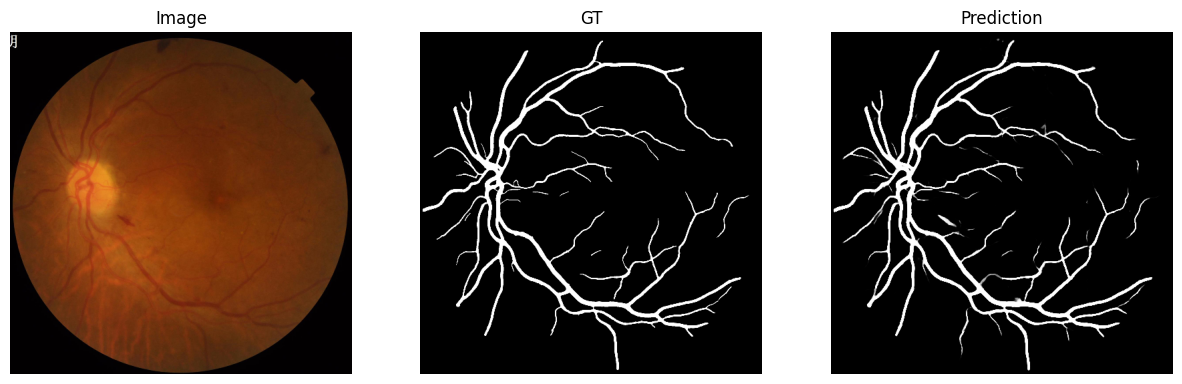

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

# ================= CONFIG =================
RESIZE_SIZE = 512
PATCH_SIZE  = 128
OVERLAP     = 0.5
STRIDE      = int(PATCH_SIZE * (1 - OVERLAP))
BATCH_SIZE  = 16          # GPU safe
THRESHOLD   = 0.5

# ================= PATCH UTILS =================
def extract_patches(img):
    H, W = img.shape[:2]
    for y in range(0, H - PATCH_SIZE + 1, STRIDE):
        for x in range(0, W - PATCH_SIZE + 1, STRIDE):
            yield img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

def stitch_patches(patches):
    full = np.zeros((RESIZE_SIZE, RESIZE_SIZE), np.float32)
    count = np.zeros_like(full)

    idx = 0
    for y in range(0, RESIZE_SIZE - PATCH_SIZE + 1, STRIDE):
        for x in range(0, RESIZE_SIZE - PATCH_SIZE + 1, STRIDE):
            full[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += patches[idx]
            count[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += 1
            idx += 1

    return np.clip(full / (count + 1e-7), 0, 1)

# ================= FULL IMAGE PRED =================
def predict_full_image(model, img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))

    patches = list(extract_patches(img))
    preds_all = []

    for i in range(0, len(patches), BATCH_SIZE):
        batch = np.array(patches[i:i+BATCH_SIZE], np.float32) / 255.0
        preds = model.predict(batch, verbose=0)
        preds_all.extend(preds[..., 0])

    return img, stitch_patches(preds_all)

# ================= EVALUATION =================
def evaluate_model(model, image_paths, mask_paths):
    dice_l, iou_l, acc_l, f1_l, se_l, sp_l, auc_l = [], [], [], [], [], [], []

    for img_p, mask_p in zip(image_paths, mask_paths):
        _, pred = predict_full_image(model, img_p)

        gt = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
        gt = cv2.resize(gt, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

        y_prob = pred.flatten()
        y_pred = (pred >= THRESHOLD).astype(np.uint8).flatten()
        y_true = (gt >= 0.5).astype(np.uint8).flatten()

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

        dice = (2*tp) / (2*tp + fp + fn + 1e-7)
        iou  = tp / (tp + fp + fn + 1e-7)
        acc  = (tp + tn) / (tp + tn + fp + fn + 1e-7)
        se   = tp / (tp + fn + 1e-7)
        sp   = tn / (tn + fp + 1e-7)
        f1   = f1_score(y_true, y_pred)
        auc  = roc_auc_score(y_true, y_prob)

        dice_l.append(dice)
        iou_l.append(iou)
        acc_l.append(acc)
        f1_l.append(f1)
        se_l.append(se)
        sp_l.append(sp)
        auc_l.append(auc)

    print(f"Dice        : {np.mean(dice_l):.4f}")
    print(f"IoU         : {np.mean(iou_l):.4f}")
    print(f"Accuracy    : {np.mean(acc_l):.4f}")
    print(f"F1-score    : {np.mean(f1_l):.4f}")
    print(f"Sensitivity : {np.mean(se_l):.4f}")
    print(f"Specificity : {np.mean(sp_l):.4f}")
    print(f"AUC         : {np.mean(auc_l):.4f}")

# ================= VISUALIZATION =================
def visualize(model, img_path, mask_path):
    img, pred = predict_full_image(model, img_path)
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt = cv2.resize(gt, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("GT"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(pred, cmap="gray"); plt.title("Prediction"); plt.axis("off")
    plt.show()

# ================= RUN =================
evaluate_model(model, test_images, test_masks)
visualize(model, test_images[0], test_masks[0])

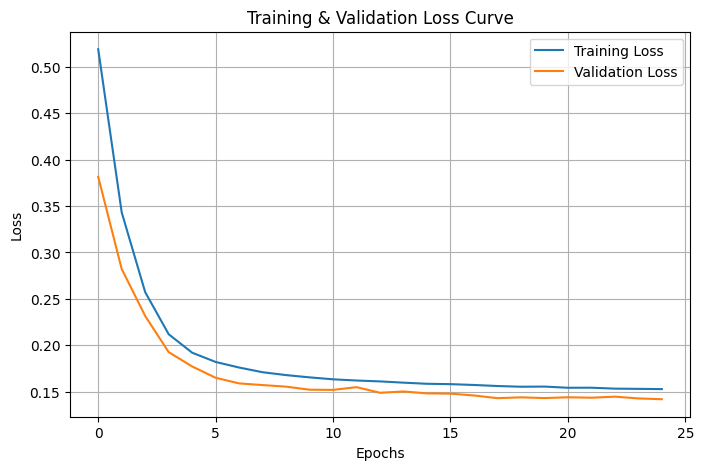

In [10]:
import matplotlib.pyplot as plt

# Plot Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
import os
import cv2
import numpy as np
import csv
from sklearn.metrics import roc_auc_score, confusion_matrix

# ================= CONFIG =================
RESIZE_SIZE = 512
PATCH_SIZE  = 128
OVERLAP     = 0.5
STRIDE      = int(PATCH_SIZE * (1 - OVERLAP))
BATCH_SIZE  = 16
THRESHOLD   = 0.5

# ================= PATHS =================
PREDICTIONS_DIR = r'C:\Users\AUSTCSE4090\Desktop\FIVES\predicted mask\transunet predicted_mask'
CSV_FILE        = r"C:\Users\AUSTCSE4090\Desktop\FIVES\csv file\transunet _final_metrics.csv"
GROUND_TRUTH_DIR = r'C:\Users\AUSTCSE4090\Desktop\FIVES\predicted mask\transunet _ground_truth_mask'
ORIGINAL_IMAGES_DIR = r'C:\Users\AUSTCSE4090\Desktop\FIVES\predicted mask\transunet original image'

os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(GROUND_TRUTH_DIR, exist_ok=True)
os.makedirs(ORIGINAL_IMAGES_DIR, exist_ok=True)

# ================= PATCH FUNCTIONS =================
def extract_patches(img):
    H, W = img.shape[:2]
    patches, positions = [], []
    for y in range(0, H - PATCH_SIZE + 1, STRIDE):
        for x in range(0, W - PATCH_SIZE + 1, STRIDE):
            patches.append(img[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
            positions.append((y, x))
    return patches, positions

def stitch_patches(patches, positions):
    full = np.zeros((RESIZE_SIZE, RESIZE_SIZE), np.float32)
    count = np.zeros_like(full)
    for p, (y, x) in zip(patches, positions):
        full[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += p
        count[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += 1
    return np.clip(full / (count + 1e-7), 0, 1)

# ================= PREDICTION =================
def predict_full_image(model, img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
    patches, positions = extract_patches(img)

    preds_all = []
    for i in range(0, len(patches), BATCH_SIZE):
        batch = np.array(patches[i:i+BATCH_SIZE], np.float32) / 255.0
        preds = model.predict(batch, verbose=0)
        preds_all.extend(preds[..., 0])

    return stitch_patches(preds_all, positions)

# ================= METRICS =================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(
        y_true.flatten(), y_pred.flatten(), labels=[0, 1]
    ).ravel()

    sens = tp / (tp + fn + 1e-7)
    spec = tn / (tn + fp + 1e-7)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    prec = tp / (tp + fp + 1e-7)
    f1   = 2 * prec * sens / (prec + sens + 1e-7)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-7)
    iou  = tp / (tp + fp + fn + 1e-7)

    try:
        auc = roc_auc_score(y_true.flatten(), y_prob.flatten())
    except:
        auc = np.nan

    return sens, spec, acc, f1, dice, iou, auc

# ================= SAVE CSV =================
with open(CSV_FILE, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(
        ["Image", "Dice", "IoU", "Accuracy", "F1", "Sensitivity", "Specificity", "AUC"]
    )

# ================= RUN EVALUATION =================
for idx, (img_path, mask_path) in enumerate(zip(test_images, test_masks)):

    # ---------- Prediction ----------
    pred_mask = predict_full_image(model, img_path)

    # ---------- Ground Truth ----------
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt = cv2.resize(gt, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    # ---------- Original Image ----------
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (RESIZE_SIZE, RESIZE_SIZE))

    y_true = (gt >= 0.5).astype(np.uint8)
    y_pred = (pred_mask >= THRESHOLD).astype(np.uint8)
    y_prob = pred_mask

    # ---------- Metrics ----------
    sens, spec, acc, f1, dice, iou, auc = compute_metrics(
        y_true, y_pred, y_prob
    )

    # ---------- Save Images ----------
    cv2.imwrite(
        os.path.join(PREDICTIONS_DIR, f"pred_mask_{idx+1}.png"),
        y_pred * 255
    )

    cv2.imwrite(
        os.path.join(GROUND_TRUTH_DIR, f"gt_mask_{idx+1}.png"),
        y_true * 255
    )

    cv2.imwrite(
        os.path.join(ORIGINAL_IMAGES_DIR, f"original_{idx+1}.png"),
        orig
    )

    # ---------- Save CSV ----------
    with open(CSV_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(
            [os.path.basename(img_path), dice, iou, acc, f1, sens, spec, auc]
        )

print("✔ Predicted masks saved to:", PREDICTIONS_DIR)
print("✔ Ground truth masks saved to:", GROUND_TRUTH_DIR)
print("✔ Original images saved to:", ORIGINAL_IMAGES_DIR)
print("✔ Metrics saved to CSV:", CSV_FILE)

✔ Predicted masks saved to: C:\Users\AUSTCSE4090\Desktop\FIVES\predicted mask\transunet predicted_mask
✔ Ground truth masks saved to: C:\Users\AUSTCSE4090\Desktop\FIVES\predicted mask\transunet _ground_truth_mask
✔ Original images saved to: C:\Users\AUSTCSE4090\Desktop\FIVES\predicted mask\transunet original image
✔ Metrics saved to CSV: C:\Users\AUSTCSE4090\Desktop\FIVES\csv file\transunet _final_metrics.csv


In [11]:
import os

# Define the folder path to save the model
folder_path = r'C:\Users\AUSTCSE4090\Desktop\FIVES\predictions'  # Update this path if needed
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Define the model save path
model_save_path = os.path.join(folder_path, 'transunet _model.h5')

# Save the model in H5 format
model.save(model_save_path)
print(f"Saved model to {model_save_path}")


Saved model to C:\Users\AUSTCSE4090\Desktop\FIVES\predictions\proposed model _model.h5


In [12]:
from tensorflow.keras import backend as K

# Clear any previous models and free memory
K.clear_session()
